# <font color=blue>Compare Regression Model Building Exercise (Linear, Ridge, Lasso, Elastic Net) </font>
### <font color=amber>Level. Intermediate</font>
This exercise consists of several phases designed to guide you through the full machine learning workflow for several regression model.

**Phase 1: Understand the Problem**
- Define the business or prediction goal.
- Identify the target variable.
- Identify the input features.
- Determine whether this is a regression or classification problem.

**Phase 2: Explore the Data (Exploratory Data Analysis - EDA)**
- Load and inspect the dataset.

**Phase 3: Prepare the Data**
- Select relevant features.
- Encode categorical variables (if any).

**Scale/normalize features if needed.**
- Split the dataset into training and testing sets (e.g., 80/20 split).

**Phase 4: Build the Regression Models (Linear, Ridge, Lasso, Elastic Net Regression)**
Using the same training and testing data, build:
1) Linear Regression
2) Ridge Regression
3) Lasso Regression
4) Elastic Net Regression
   - Tune hyperparameters (e.g., alpha).
   - Use cross-validation for better model selection.
- Examine model coefficients.
- Understand the intercept and feature importance.

**Phase 5: Evaluate the Regression Models (Linear, Ridge, Lasso, Elastic Net Regression)**
- Make predictions on the test set.
- Calculate evaluation metrics:
  - MAE (Mean Absolute Error)
  - RMSE (Root Mean Squared Error)
  - R² (R-squared)
-Compare training vs. testing performance (check for overfitting).

**Phase 6: Compare Model Performance**
- Compare MAE, RMSE, and R² across all models.
- Analyze bias vs. variance.
- Identify the best-performing model.

**Phase 7: Model Interpretation**
- Interpret coefficients.
- Understand how each feature impacts the prediction.
- Discuss regularization effects (Ridge vs. Lasso vs. Elastic Net).

**Phase 8: Final Conclusions**
- Select the best model.
- Summarize findings.
- Suggest possible improvements (more data, feature engineering, different algorithms).

# <font color=blue> LinearRegression </font>
**👉 What it is:**
Basic model that finds a straight-line relationship between inputs (features) and output.

**✅ When to use:**
- You have **simple relationships**
- Features are **not highly correlated**
- You want **easy interpretability**

**🧠 Real-life examples:**
- Predicting **house price** based on size, bedrooms, location
- Estimating **salary** from years of experience
- Forecasting **sales** from advertising spend

**⚠️ Limitation:**
- Breaks when there are **too many features** or **multicollinearity (features highly correlated)**

### Generic libraries (e.g. Math, Plot etc.)

In [1]:
# Import core libraries for numerical computing, data analysis, visualization, and suppress warnings
import numpy as np # Numerical Python, supports homogeneous data types
import pandas as pd ## Built on top of NumPy, supports heterogeneous data type
import matplotlib.pyplot as plt # Plots 2D graphs and plots. Used for data visualization, e.g. histogram, bar chart, error chart etc.
import seaborn as sns # Built on top of Matplotlib. Less code & can plot heatmap, pairplot, violinplot etc.
import warnings # Python's built-in module to manage warnings.
warnings.filterwarnings("ignore") # Suppresses all warning messages for cleaner output.

### ML model libraries (e.g. Linear regression, Classification etc.)

In [2]:
# import model libraries
from sklearn.model_selection import train_test_split # Used to split arrays or matrices into random train and test subsets
from sklearn.linear_model import LinearRegression # Imports the Linear Regression model
from sklearn.linear_model import Ridge ## Ridge regression
from sklearn.linear_model import Lasso ## Lasso regression
from sklearn.linear_model import ElasticNet ## Elastic Net regression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error # Imports metrics for evaluating regression models
# from sklearn.datasets import fetch_openml # Used to fetch datasets from OpenML

In [3]:
# Load Diamonds dataset
# diamonds dataset: https://ggplot2.tidyverse.org/reference/diamonds.html
df = sns.load_dataset("diamonds")

In [4]:
# Checking the data
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [5]:
# separting features and target
X = df.drop("price",axis=1)
y = df[["price"]]

In [6]:
# display features
X

,carat,cut,color,clarity,depth,table,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,6.15,6.12,3.74


In [7]:
# getting dummies and dropping first
X_dummy = pd.get_dummies(X,drop_first=True)

In [8]:
# data after getting dummy variables
X_dummy

,carat,depth,table,x,y,z,cut_Premium,cut_Very Good,cut_Good,cut_Fair,...,color_H,color_I,color_J,clarity_VVS1,clarity_VVS2,clarity_VS1,clarity_VS2,clarity_SI1,clarity_SI2,clarity_I1
0,0.23,61.5,55.0,3.95,3.98,2.43,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,0.21,59.8,61.0,3.89,3.84,2.31,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,0.23,56.9,65.0,4.05,4.07,2.31,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False
3,0.29,62.4,58.0,4.20,4.23,2.63,True,False,False,False,...,False,True,False,False,False,False,True,False,False,False
4,0.31,63.3,58.0,4.34,4.35,2.75,False,False,True,False,...,False,False,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.72,60.8,57.0,5.75,5.76,3.50,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
53936,0.72,63.1,55.0,5.69,5.75,3.61,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
53937,0.70,62.8,60.0,5.66,5.68,3.56,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
53938,0.86,61.0,58.0,6.15,6.12,3.74,True,False,False,False,...,True,False,False,False,False,False,False,False,True,False


In [9]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_dummy, y, test_size=0.2, random_state=42)

# <font color=blue> Regularization - What is L1 and L2 regularization? </font>
- Regularization eliminate or reduce the cofficeent of feature to **zero** if not needed. At a high level, L1 and L2 regularization are ways to “penalize” model complexity so your model doesn’t overfit the data.

###🔹 Without regularization
- A model tries to fit the training data as closely as possible → can lead to:
    - Overfitting
    - Huge, unstable coefficients

###🔹 With regularization
- We add a penalty for large coefficients, forcing the model to stay simpler.

## L1 Regularization (Lasso)
   - **If a feature isn’t useful, eliminate it completely.**

## L2 Regularization (Ridge)
   - **“All features matter, but let’s tone them down.”**

# <font color=blue> Ridge Regression (L2 Regularization) </font>
Ridge regression adds a penalty term (L2 regularization) to the linear regression cost function. It helps prevent overfitting by forcing the coefficients to be small.

**👉 What it does:**
Adds a penalty to shrink coefficients (but **never makes them zero**)

**✅ When to use:**
- You have **many features**
- Features are **highly correlated**
- You want to **reduce overfitting**, but keep all variables

**🧠 Real-life examples:**
- Predicting **stock prices** using dozens of financial indicators
- Modeling **customer behavior** with many overlapping variables (age, income, spending habits)
- Healthcare: predicting outcomes using many correlated biomarkers

**💡 Key idea:**
👉 Keeps all features, just **reduces their impact**

# <font color=blue> Lasso Regression (L1 Regularization) </font>
Lasso regression also adds a penalty term (L1 regularization) to the linear regression cost function. It not only prevents overfitting but also tends to force some coefficients to be exactly zero, effectively performing feature selection.


**👉 What it does:**
Adds penalty that can shrink some coefficients to **exactly zero** → automatic **feature selection**

**✅ When to use:**
- You want a **simpler model**
- You suspect **only a few features actually matter**
- You need **interpretability + feature selection**

**🧠 Real-life examples:**
- Identifying **key factors affecting house prices** (maybe only 5 out of 50 matter)
- Marketing: finding which campaigns actually drive sales
- Genomics: selecting important genes from thousands

**💡 Key idea:**
👉 **Eliminates irrelevant features**

# <font color=blue> Elastic Net (Ridge + Lasso combined </font>
Elastic Net is a combination of Ridge and Lasso regression. It adds both L1 and L2 regularization terms to the cost function. This provides a balance between the two regularization methods.

**👉 What it does:**
Combines L1 + L2 penalties → balance between shrinkage and feature selection

**✅ When to use:**
- You have:
  - **Many features**
  - **Correlated features**
- You want:
  - Some **feature selection**
  - But also **stability like Ridge**

**🧠 Real-life examples:**
- Predicting **user churn** with hundreds of behavioral metrics
- Credit scoring with many correlated financial variables
- Text analysis (NLP) with thousands of features (words)

**💡 Key idea:**
👉 Best of both worlds

# <font color=blue> 🎯 Simple Rule of Thumb </font>
## - 👉 Start with Linear Regression
## - 👉 If overfitting → try Ridge
## - 👉 If too many useless features → try Lasso
## - 👉 If both problems exist → use Elastic Net

In [10]:
# Initialize the regression models
# Linear Regression: No regularization applied.
lr = LinearRegression()

# Ridge Regression (L2 regularization): 'alpha' controls the strength of the L2 penalty.
# A larger alpha means stronger regularization, forcing coefficients closer to zero.
ridge = Ridge(alpha=0.1)

# Lasso Regression (L1 regularization): 'alpha' controls the strength of the L1 penalty.
# A larger alpha means stronger regularization, potentially driving some coefficients exactly to zero (feature selection).
lasso = Lasso(alpha=0.1)

# Elastic Net Regression (L1 + L2 regularization): 'alpha' is the total regularization strength.
# 'l1_ratio' (default 0.5) controls the mix between L1 and L2 penalties.
elastic_net = ElasticNet(alpha=0.1)

# Lists to store Root Mean Squared Error (RMSE) values for test sets and model names for easy comparison.
rmse = []
model_names = ["Linear Regression", "Ridge", "Lasso", "Elastic Net"]
models = [lr, ridge, lasso, elastic_net]

# Loop through each defined model to train, predict, and evaluate its performance.
for model, name in zip(models, model_names):
  # Train the current model using the training data (features X_train, target y_train).
  model.fit(X_train, y_train)

  # Make predictions on the training set to check for potential overfitting.
  y_pred_train = model.predict(X_train)

  # Make predictions on the unseen test set to evaluate generalization performance.
  y_pred_test = model.predict(X_test)

  # Calculate the Root Mean Squared Error (RMSE) for the test set.
  # RMSE measures the average magnitude of the errors. Lower values indicate better fit.
  rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

  # Store the test RMSE for later visualization or comparison.
  rmse.append(rmse_test)

  # Print the name of the current model being evaluated.
  print(name)

  # Print the RMSE for the training set.
  print("RMSE training", np.sqrt(mean_squared_error(y_train, y_pred_train)))

  # Print the RMSE for the test set.
  print("RMSE testing", np.sqrt(mean_squared_error(y_test, y_pred_test)))

Linear Regression
RMSE training 1128.5697163572002
RMSE testing 1135.2116445190625
Ridge
RMSE training 1128.569767631579
RMSE testing 1135.2056401289703
Lasso
RMSE training 1128.5802189855656
RMSE testing 1135.1062988910749
Elastic Net
RMSE training 1555.5961521321703
RMSE testing 1532.116286609904


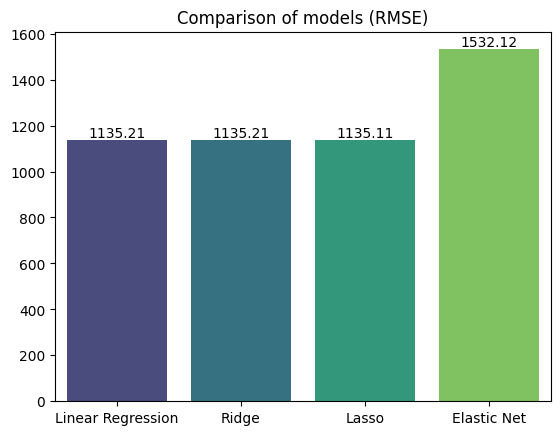

In [13]:
# Create a bar plot to compare the RMSE values of the different regression models.
# 'x' axis represents the model names, 'y' axis represents the RMSE values.
# 'palette='viridis'' sets the color scheme for the bars.
ax = sns.barplot(x=model_names, y=rmse, palette='viridis')

# Set the title of the plot for clarity.
plt.title("Comparison of models (RMSE)")

# Add text annotations on top of each bar to display the exact RMSE value.
# 'ax.containers' iterates through the bar containers in the plot.
# 'ax.bar_label(container, fmt='%.2f')' adds a label to each bar, formatted to two decimal places.
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')